# Hurricane Helene (2024) — AI Model Track Comparison

Compare tropical cyclone tracks from **GraphCast**, **FCN3**, and **AIFS**
against ERA5 reanalysis for Hurricane Helene, at three lead times before
landfall (T−72 h, T−168 h, T−240 h).

**Verification target:** Helene's Florida Big Bend landfall,
snapped to `2024-09-27 00:00 UTC`.

| Lead | Init time (UTC)  | Steps (6 h) |
|------|------------------|-------------|
| 72 h | 2024-09-24 00:00 | 12          |
| 168 h| 2024-09-20 00:00 | 28          |
| 240 h| 2024-09-17 00:00 | 40          |

In [2]:
import os

# Must be set BEFORE importing torch.
os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"


  FORCE_CUDA_EXTENSION = 1
  TORCH_CUDA_ARCH_LIST = 8.9
  CUDA_HOME = /usr/local/cuda
  EARTH2STUDIO_CACHE = /home/jovyan/.cache/earth2studio
sdfsf

In [3]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

from earth2studio.models.px import FCN3, AIFS
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import WB2ERA5, ARCO, IFS, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("Done")

/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead. parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failedCuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this featureDevice: cuda
GPU   : NVIDIA L40
VRAM  : 47.7 GB
Done

In [4]:
#storm config
STORM_NAME = "Helene"

VERIFICATION_TIME = datetime(2024, 9, 27, 0)

LEAD_TIMES_H = [72, 168, 240]

# Derived: init time and step count for each lead.
INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

OUT_DIR = Path("./outputs/helene")
OUT_DIR.mkdir(parents=True, exist_ok=True)


PLOT_EXTENT = (-100, -65, 15, 40)

LANDFALL_LAT = 30.0
LANDFALL_LON = -83.7

MODEL_COLORS = {
    "FCN3":      "#ff7f0e",  # orange
    "AIFS":      "#2ca02c",  # green
    "GraphCast": "#1f77b4",  # blue
    "ERA5":      "#000000",  # black
}

# Print the resolved init times.
for h in LEAD_TIMES_H:
    print(f"  T-{h:>3}h : init={INIT_TIMES[h]}  steps={N_STEPS[h]}")

  T- 72h : init=2024-09-24 00:00:00  steps=12
  T-168h : init=2024-09-20 00:00:00  steps=28
  T-240h : init=2024-09-17 00:00:00  steps=40

In [5]:
def run_tc_inference(prognostic, data_source, start_time, nsteps, save_path):
    """Run a prognostic model through TCTrackerWuDuan and save tracks.

    Args:
        prognostic:   Loaded Earth2Studio prognostic model.
        data_source:  Data source for initial conditions (e.g. WB2ERA5).
        start_time:   datetime — forecast initialization time.
        nsteps:       Number of 6h autoregressive steps.
        save_path:    Path to save the output .pt track tensor.

    Returns:
        torch.Tensor of shape (batch, num_paths, time_steps, 2).
    """
    # Skip if already cached — avoids re-running expensive inference.
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    # Move model to GPU.
    prognostic = prognostic.to(DEVICE)

    # Fresh tracker instance per run — reset_path_buffer clears any
    # leftover state from a previous call.
    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    # Fetch initial condition from the data source.
    # fetch_data returns (tensor, coords_dict) on the target device.
    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    # Align coords to the model's expected layout.
    x, coords = map_coords(x, coords, prognostic.input_coords())

    # Step through the autoregressive iterator.
    # Each iteration: model produces next state → tracker ingests it.
    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        # map_coords aligns the model output to tracker's expected vars.
        x, coords = map_coords(x, coords, tracker.input_coords())
        # Tracker call: updates internal path buffer, returns current tracks.
        output, _ = tracker(x, coords)
        output = output[:, 0]  # take the first (and usually only) batch dim
        if step == nsteps:
            break

    # Save tracks as a .pt tensor for fast reload.
    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}")
    return tracks

In [ ]:
def run_era5_truth(data_source, start_time, nsteps, save_path):
    """Track ERA5 reanalysis with TCTrackerWuDuan over the same time window as a forecast."""
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
    for step, time in tqdm(enumerate(times), total=len(times)):
        try:
            da = data_source(time, tracker.input_coords()["variable"])
        except RuntimeError:
            # Corrupted cache chunk — retry with a fresh uncached download.
            from earth2studio.data import ARCO
            da = ARCO(cache=False)(time, tracker.input_coords()["variable"])
        x, coords = prep_data_array(da, device=DEVICE)
        output, _ = tracker(x, coords)

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  → {save_path}")
    return tracks

In [6]:
# ARCO = Analysis-Ready, Cloud Optimized ERA5 on GCS.
# Used for both model initialization and ERA5 truth tracking.
# WB2ERA5 has a hard cutoff of 2023-01-11 — all Helene init times are in Sep 2024.
data_source = ARCO(cache=True)

2026-05-04 15:49:34.430 | DEBUG    | earth2studio.data.arco:_async_init:127 - Using Multi-Storage Client for ARCO data access

In [16]:
from earth2studio.data import CDS

# Replace your current ifs_data_source with this:
aifs_data_source = CDS(cache=True)

In [24]:
# ARCO = Analysis-Ready, Cloud Optimized ERA5 on GCS.
# Used for both model initialization and ERA5 truth tracking.
# WB2ERA5 has a hard cutoff of 2023-01-11 — all Helene init times are in Sep 2024.
data_source = ARCO(cache=True)

2026-05-04 17:23:00.392 | DEBUG    | earth2studio.data.arco:_async_init:127 - Using Multi-Storage Client for ARCO data access

In [12]:
from earth2studio.data import CDS

# Replace your current ifs_data_source with this:
aifs_data_source = CDS(cache=True)

## AIFS forecasts

AIFS (ECMWF) — GNN encoder + sliding-window transformer processor.
First ML model fully operational at a major NWP center (Feb 2025).

In [17]:
%%time
aifs = AIFS.load_model(AIFS.load_default_package())

CPU times: user 5.22 s, sys: 564 ms, total: 5.78 s
Wall time: 5.75 s

In [19]:
%%time
aifs_tracks_72 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "aifs_72h.pt",
)

2026-05-04 16:08:27.949 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-09-23 18:00:00 with 1 levels2026-05-04 16:08:28.822 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:81368ee0-c81e-46b8-a36e-6a2d6a8a2ec5, state: accepted2026-05-04 16:08:31.001 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:81368ee0-c81e-46b8-a36e-6a2d6a8a2ec5, state: accepted2026-05-04 16:08:34.208 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:81368ee0-c81e-46b8-a36e-6a2d6a8a2ec5, state: accepted2026-05-04 16:08:36.395 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:81368ee0-c81e-46b8-a36e-6a2d6a8a2ec5, state: accepted2026-05-04 16:08:38.587 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:81368ee0-c81e-46b8-a36e-6a2d6a8a2ec5, state: accepted2026-05-04 16:08:40.780 | DEBUG    | earth2studi

2026-05-04 16:08:58.472 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-09-23 18:00:00 with 1 levels2026-05-04 16:08:59.453 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b252533c-3b0e-4a42-a291-db7ecde76484, state: accepted2026-05-04 16:09:01.629 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b252533c-3b0e-4a42-a291-db7ecde76484, state: accepted2026-05-04 16:09:03.804 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b252533c-3b0e-4a42-a291-db7ecde76484, state: accepted2026-05-04 16:09:06.083 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b252533c-3b0e-4a42-a291-db7ecde76484, state: accepted2026-05-04 16:09:08.252 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b252533c-3b0e-4a42-a291-db7ecde76484, state: accepted2026-05-04 16:09:10.422 | DEBUG    | earth2studi

2026-05-04 16:09:19.166 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-09-23 18:00:00 with 1 levels2026-05-04 16:09:20.030 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9ff042e1-e048-4903-9ee9-b461a78a7fb3, state: accepted2026-05-04 16:09:22.224 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9ff042e1-e048-4903-9ee9-b461a78a7fb3, state: accepted2026-05-04 16:09:24.396 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9ff042e1-e048-4903-9ee9-b461a78a7fb3, state: accepted2026-05-04 16:09:26.567 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9ff042e1-e048-4903-9ee9-b461a78a7fb3, state: accepted2026-05-04 16:09:28.738 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:9ff042e1-e048-4903-9ee9-b461a78a7fb3, state: accepted2026-05-04 16:09:30.935 | DEBUG    | earth2studi

2026-05-04 16:09:45.419 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_temperature at 2024-09-23 18:00:00 with 1 levels2026-05-04 16:09:48.072 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:59c852b5-7f89-4ed1-9673-19084397866f, state: accepted2026-05-04 16:09:50.252 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:59c852b5-7f89-4ed1-9673-19084397866f, state: accepted2026-05-04 16:09:52.431 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:59c852b5-7f89-4ed1-9673-19084397866f, state: accepted2026-05-04 16:09:54.602 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:59c852b5-7f89-4ed1-9673-19084397866f, state: accepted2026-05-04 16:09:56.795 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:59c852b5-7f89-4ed1-9673-19084397866f, state: accepted2026-05-04 16:09:58.969 | DEBUG    | earth2studio.data.cd

2026-05-04 16:10:16.796 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-09-23 18:00:00 with 1 levels2026-05-04 16:10:17.862 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:010a6601-bdc7-41f2-9382-50ef876b3cee, state: accepted2026-05-04 16:10:20.053 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:010a6601-bdc7-41f2-9382-50ef876b3cee, state: accepted2026-05-04 16:10:22.233 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:010a6601-bdc7-41f2-9382-50ef876b3cee, state: accepted2026-05-04 16:10:24.402 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:010a6601-bdc7-41f2-9382-50ef876b3cee, state: accepted2026-05-04 16:10:26.573 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:010a6601-bdc7-41f2-9382-50ef876b3cee, state: accepted2026-05-04 16:10:28.743 | DEBUG    | earth2studi

...

2026-05-04 16:25:02.047 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: volumetric_soil_water_layer_2 at 2024-09-24 00:00:00 with 1 levels2026-05-04 16:25:02.847 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:1b384ad7-94ee-47d6-af4c-866fd17e0c6c, state: accepted2026-05-04 16:25:05.018 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:1b384ad7-94ee-47d6-af4c-866fd17e0c6c, state: accepted2026-05-04 16:25:07.189 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:1b384ad7-94ee-47d6-af4c-866fd17e0c6c, state: accepted2026-05-04 16:25:09.358 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:1b384ad7-94ee-47d6-af4c-866fd17e0c6c, state: accepted2026-05-04 16:25:11.549 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:1b384ad7-94ee-47d6-af4c-866fd17e0c6c, state: accepted2026-05-04 16:25:13.721 | DEBUG    | earth

2026-05-04 16:25:22.299 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_1 at 2024-09-24 00:00:00 with 1 levels2026-05-04 16:25:23.363 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fb13558e-ffe4-4676-88ab-b9eabffda336, state: accepted2026-05-04 16:25:25.534 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fb13558e-ffe4-4676-88ab-b9eabffda336, state: accepted2026-05-04 16:25:27.726 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fb13558e-ffe4-4676-88ab-b9eabffda336, state: accepted2026-05-04 16:25:29.898 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fb13558e-ffe4-4676-88ab-b9eabffda336, state: accepted2026-05-04 16:25:32.066 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:fb13558e-ffe4-4676-88ab-b9eabffda336, state: accepted2026-05-04 16:25:34.243 | DEBUG    | earth2stud

2026-05-04 16:25:51.946 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_2 at 2024-09-24 00:00:00 with 1 levels2026-05-04 16:25:54.411 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2b5b328b-0435-4198-9092-68e3117dadc5, state: accepted2026-05-04 16:25:56.593 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2b5b328b-0435-4198-9092-68e3117dadc5, state: accepted2026-05-04 16:25:58.779 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2b5b328b-0435-4198-9092-68e3117dadc5, state: accepted2026-05-04 16:26:00.954 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2b5b328b-0435-4198-9092-68e3117dadc5, state: accepted2026-05-04 16:26:03.405 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:2b5b328b-0435-4198-9092-68e3117dadc5, state: accepted2026-05-04 16:26:05.573 | DEBUG    | earth2stud

 92%|█████████▏| 12/13 [00:55<00:04,  4.62s/it]

  saved  → outputs/helene/aifs_72h.pt
CPU times: user 46.1 s, sys: 2.44 s, total: 48.6 s
Wall time: 18min 47s

In [21]:
%%time
aifs_tracks_168 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "aifs_168h.pt",
)

2026-05-04 16:29:53.455 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-09-19 18:00:00 with 1 levels2026-05-04 16:29:55.022 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4c94bdaa-858a-4b85-a8a7-70b7fd5bc6b5, state: accepted2026-05-04 16:29:57.228 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4c94bdaa-858a-4b85-a8a7-70b7fd5bc6b5, state: accepted2026-05-04 16:29:59.427 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4c94bdaa-858a-4b85-a8a7-70b7fd5bc6b5, state: accepted2026-05-04 16:30:01.626 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4c94bdaa-858a-4b85-a8a7-70b7fd5bc6b5, state: accepted2026-05-04 16:30:03.810 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:4c94bdaa-858a-4b85-a8a7-70b7fd5bc6b5, state: accepted2026-05-04 16:30:05.994 | DEBUG    | earth2studi

2026-05-04 16:30:27.663 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-09-19 18:00:00 with 1 levels2026-05-04 16:30:28.672 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3a23c574-8a06-4a75-a53e-b00835b5dc7e, state: accepted2026-05-04 16:30:30.844 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3a23c574-8a06-4a75-a53e-b00835b5dc7e, state: accepted2026-05-04 16:30:33.037 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3a23c574-8a06-4a75-a53e-b00835b5dc7e, state: accepted2026-05-04 16:30:36.646 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3a23c574-8a06-4a75-a53e-b00835b5dc7e, state: accepted2026-05-04 16:30:38.973 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:3a23c574-8a06-4a75-a53e-b00835b5dc7e, state: accepted2026-05-04 16:30:41.145 | DEBUG    | earth2studi

2026-05-04 16:30:57.261 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-09-19 18:00:00 with 1 levels2026-05-04 16:30:58.026 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:39e7b353-d170-4eec-a8e2-bcf8f1459c48, state: accepted2026-05-04 16:31:00.215 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:39e7b353-d170-4eec-a8e2-bcf8f1459c48, state: accepted2026-05-04 16:31:02.385 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:39e7b353-d170-4eec-a8e2-bcf8f1459c48, state: accepted2026-05-04 16:31:04.582 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:39e7b353-d170-4eec-a8e2-bcf8f1459c48, state: accepted2026-05-04 16:31:06.772 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:39e7b353-d170-4eec-a8e2-bcf8f1459c48, state: accepted2026-05-04 16:31:08.943 | DEBUG    | earth2studi

2026-05-04 16:31:24.165 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_temperature at 2024-09-19 18:00:00 with 1 levels2026-05-04 16:31:25.517 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:0977b2d7-e6dd-4eb7-8912-c6347459fe2a, state: accepted2026-05-04 16:31:27.690 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:0977b2d7-e6dd-4eb7-8912-c6347459fe2a, state: accepted2026-05-04 16:31:29.861 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:0977b2d7-e6dd-4eb7-8912-c6347459fe2a, state: accepted2026-05-04 16:31:32.034 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:0977b2d7-e6dd-4eb7-8912-c6347459fe2a, state: accepted2026-05-04 16:31:34.216 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:0977b2d7-e6dd-4eb7-8912-c6347459fe2a, state: accepted2026-05-04 16:31:36.392 | DEBUG    | earth2studio.data.cd

2026-05-04 16:31:54.645 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-09-19 18:00:00 with 1 levels2026-05-04 16:31:55.494 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a9bd7d74-784a-4c5f-a3d0-9bb4b436dc9f, state: accepted2026-05-04 16:31:57.705 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a9bd7d74-784a-4c5f-a3d0-9bb4b436dc9f, state: accepted2026-05-04 16:31:59.878 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a9bd7d74-784a-4c5f-a3d0-9bb4b436dc9f, state: accepted2026-05-04 16:32:02.055 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a9bd7d74-784a-4c5f-a3d0-9bb4b436dc9f, state: accepted2026-05-04 16:32:04.229 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:a9bd7d74-784a-4c5f-a3d0-9bb4b436dc9f, state: accepted2026-05-04 16:32:06.402 | DEBUG    | earth2studi

...

2026-05-04 16:46:00.396 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: volumetric_soil_water_layer_2 at 2024-09-20 00:00:00 with 1 levels2026-05-04 16:46:01.286 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:334239ec-9e51-437f-80b6-dd2124e80b97, state: accepted2026-05-04 16:46:03.464 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:334239ec-9e51-437f-80b6-dd2124e80b97, state: accepted2026-05-04 16:46:05.649 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:334239ec-9e51-437f-80b6-dd2124e80b97, state: accepted2026-05-04 16:46:07.833 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:334239ec-9e51-437f-80b6-dd2124e80b97, state: accepted2026-05-04 16:46:10.003 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:334239ec-9e51-437f-80b6-dd2124e80b97, state: accepted2026-05-04 16:46:12.632 | DEBUG    | earth

2026-05-04 16:46:25.869 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_1 at 2024-09-20 00:00:00 with 1 levels2026-05-04 16:46:27.736 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:05a59c59-6301-4b05-bdc9-3aa472654499, state: accepted2026-05-04 16:46:29.908 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:05a59c59-6301-4b05-bdc9-3aa472654499, state: accepted2026-05-04 16:46:32.079 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:05a59c59-6301-4b05-bdc9-3aa472654499, state: accepted2026-05-04 16:46:34.252 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:05a59c59-6301-4b05-bdc9-3aa472654499, state: accepted2026-05-04 16:46:36.427 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:05a59c59-6301-4b05-bdc9-3aa472654499, state: accepted2026-05-04 16:46:40.019 | DEBUG    | earth2stud

2026-05-04 16:46:53.822 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_2 at 2024-09-20 00:00:00 with 1 levels2026-05-04 16:46:55.056 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:8ffaa717-6b7c-43df-966f-297e1edbc272, state: accepted2026-05-04 16:46:57.228 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:8ffaa717-6b7c-43df-966f-297e1edbc272, state: accepted2026-05-04 16:46:59.400 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:8ffaa717-6b7c-43df-966f-297e1edbc272, state: accepted2026-05-04 16:47:01.569 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:8ffaa717-6b7c-43df-966f-297e1edbc272, state: accepted2026-05-04 16:47:03.776 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:8ffaa717-6b7c-43df-966f-297e1edbc272, state: accepted2026-05-04 16:47:05.950 | DEBUG    | earth2stud

 97%|█████████▋| 28/29 [00:30<00:01,  1.09s/it]

  saved  → outputs/helene/aifs_168h.pt
CPU times: user 36.3 s, sys: 2.03 s, total: 38.3 s
Wall time: 17min 56s

In [22]:
%%time
aifs_tracks_240 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "aifs_240h.pt",
)

2026-05-04 17:00:31.947 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-09-16 18:00:00 with 1 levels2026-05-04 17:00:34.575 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:c07776a9-b485-4662-b789-7bdee2daca80, state: accepted2026-05-04 17:00:36.753 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:c07776a9-b485-4662-b789-7bdee2daca80, state: accepted2026-05-04 17:00:38.947 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:c07776a9-b485-4662-b789-7bdee2daca80, state: accepted2026-05-04 17:00:41.131 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:c07776a9-b485-4662-b789-7bdee2daca80, state: accepted2026-05-04 17:00:43.323 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:c07776a9-b485-4662-b789-7bdee2daca80, state: accepted2026-05-04 17:00:45.884 | DEBUG    | earth2studi

2026-05-04 17:01:06.867 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-09-16 18:00:00 with 1 levels2026-05-04 17:01:07.645 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b819c0a3-d324-4d17-87e1-485bc7abac3d, state: accepted2026-05-04 17:01:11.235 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b819c0a3-d324-4d17-87e1-485bc7abac3d, state: accepted2026-05-04 17:01:13.403 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b819c0a3-d324-4d17-87e1-485bc7abac3d, state: accepted2026-05-04 17:01:15.977 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b819c0a3-d324-4d17-87e1-485bc7abac3d, state: accepted2026-05-04 17:01:18.145 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:b819c0a3-d324-4d17-87e1-485bc7abac3d, state: accepted2026-05-04 17:01:20.313 | DEBUG    | earth2studi

2026-05-04 17:01:36.500 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-09-16 18:00:00 with 1 levels2026-05-04 17:01:37.326 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d10bf0e3-e658-4296-91f5-562c673f7346, state: accepted2026-05-04 17:01:39.533 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d10bf0e3-e658-4296-91f5-562c673f7346, state: accepted2026-05-04 17:01:41.866 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d10bf0e3-e658-4296-91f5-562c673f7346, state: accepted2026-05-04 17:01:44.050 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d10bf0e3-e658-4296-91f5-562c673f7346, state: accepted2026-05-04 17:01:46.294 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d10bf0e3-e658-4296-91f5-562c673f7346, state: accepted2026-05-04 17:01:48.462 | DEBUG    | earth2studi

2026-05-04 17:01:57.275 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: 2m_temperature at 2024-09-16 18:00:00 with 1 levels2026-05-04 17:01:58.138 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:79b6d983-1d7a-423f-955f-2b09eff7783e, state: accepted2026-05-04 17:02:00.307 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:79b6d983-1d7a-423f-955f-2b09eff7783e, state: accepted2026-05-04 17:02:02.474 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:79b6d983-1d7a-423f-955f-2b09eff7783e, state: accepted2026-05-04 17:02:04.643 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:79b6d983-1d7a-423f-955f-2b09eff7783e, state: accepted2026-05-04 17:02:06.815 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:79b6d983-1d7a-423f-955f-2b09eff7783e, state: accepted2026-05-04 17:02:09.008 | DEBUG    | earth2studio.data.cd

2026-05-04 17:02:26.539 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-09-16 18:00:00 with 1 levels2026-05-04 17:02:27.333 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d15dfa07-2805-420f-bb03-106d6da881b2, state: accepted2026-05-04 17:02:29.504 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d15dfa07-2805-420f-bb03-106d6da881b2, state: accepted2026-05-04 17:02:31.680 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d15dfa07-2805-420f-bb03-106d6da881b2, state: accepted2026-05-04 17:02:33.850 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d15dfa07-2805-420f-bb03-106d6da881b2, state: accepted2026-05-04 17:02:38.025 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:d15dfa07-2805-420f-bb03-106d6da881b2, state: accepted2026-05-04 17:02:40.200 | DEBUG    | earth2studi

...

2026-05-04 17:17:13.127 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: volumetric_soil_water_layer_2 at 2024-09-17 00:00:00 with 1 levels2026-05-04 17:17:14.253 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:45b45b8d-52c5-478c-b196-eaff64717cf3, state: accepted2026-05-04 17:17:16.422 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:45b45b8d-52c5-478c-b196-eaff64717cf3, state: accepted2026-05-04 17:17:18.591 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:45b45b8d-52c5-478c-b196-eaff64717cf3, state: accepted2026-05-04 17:17:20.775 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:45b45b8d-52c5-478c-b196-eaff64717cf3, state: accepted2026-05-04 17:17:22.959 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:45b45b8d-52c5-478c-b196-eaff64717cf3, state: accepted2026-05-04 17:17:25.148 | DEBUG    | earth

2026-05-04 17:17:47.416 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_1 at 2024-09-17 00:00:00 with 1 levels2026-05-04 17:17:49.373 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ed5703ac-5565-49cb-9e8b-46d9e1543099, state: accepted2026-05-04 17:17:51.995 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ed5703ac-5565-49cb-9e8b-46d9e1543099, state: accepted2026-05-04 17:17:54.189 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ed5703ac-5565-49cb-9e8b-46d9e1543099, state: accepted2026-05-04 17:17:56.370 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ed5703ac-5565-49cb-9e8b-46d9e1543099, state: accepted2026-05-04 17:17:58.542 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:ed5703ac-5565-49cb-9e8b-46d9e1543099, state: accepted2026-05-04 17:18:00.717 | DEBUG    | earth2stud

2026-05-04 17:18:13.798 | INFO     | earth2studio.data.cds:_fetch_process:173 - Fetching CDS grib file for variable: soil_temperature_level_2 at 2024-09-17 00:00:00 with 1 levels2026-05-04 17:18:14.640 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:51d6a152-f366-43c0-ba6d-53b17b5bc84b, state: accepted2026-05-04 17:18:16.808 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:51d6a152-f366-43c0-ba6d-53b17b5bc84b, state: accepted2026-05-04 17:18:18.982 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:51d6a152-f366-43c0-ba6d-53b17b5bc84b, state: accepted2026-05-04 17:18:21.152 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:51d6a152-f366-43c0-ba6d-53b17b5bc84b, state: accepted2026-05-04 17:18:23.344 | DEBUG    | earth2studio.data.cds:_download_cds_grib_cached:321 - Request ID:51d6a152-f366-43c0-ba6d-53b17b5bc84b, state: accepted2026-05-04 17:18:25.521 | DEBUG    | earth2stud

 98%|█████████▊| 40/41 [00:32<00:00,  1.25it/s]

  saved  → outputs/helene/aifs_240h.pt
CPU times: user 38 s, sys: 1.84 s, total: 39.9 s
Wall time: 18min 41s

## ERA5 truth tracks

Run the same `TCTrackerWuDuan` on ERA5 reanalysis for each lead-time
window. This ensures truth and forecasts use an identical tracking
algorithm — no confound from different tracker implementations.

In [25]:
%%time
# One truth track per lead time. Each covers [init_time, verification_time].
era5_tracks_72 = run_era5_truth(
    data_source, INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "era5_72h.pt",
)

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-04 17:23:14.731 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-24T00:00:00
2026-05-04 17:23:14.734 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-24T00:00:00
2026-05-04 17:23:14.736 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-24T00:00:00
2026-05-04 17:23:14.739 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-24T00:00:00
2026-05-04 17:23:14.741 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-24T00:00:00
2026-05-04 17:23:14.814 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/mean_sea_level_pressure/1093368.0.0 to local cache
2026-05-04 17:23:14.849 | DEBUG    | earth2studio.data.utils:_mak

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-04 17:23:15.285 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/1093368.0.0 to local cache
2026-05-04 17:23:15.291 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_u_component_of_wind/1093368.0.0 to local cache

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

...

2026-05-04 17:26:55.334 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-26T18:00:00
2026-05-04 17:26:55.336 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-26T18:00:00
2026-05-04 17:26:55.338 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-26T18:00:00
2026-05-04 17:26:55.340 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-26T18:00:00
2026-05-04 17:26:55.342 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-26T18:00:00
2026-05-04 17:26:55.427 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/u_component_of_wind/1093434.0.0.0 to local cache
2026-05-04 17:26:55.453 | DEBUG    | earth2studio.data.utils:_make_

Fetching ARCO data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-04 17:27:16.609 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-27T00:00:00
2026-05-04 17:27:16.611 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-27T00:00:00
2026-05-04 17:27:16.613 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-27T00:00:00
2026-05-04 17:27:16.615 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-27T00:00:00
2026-05-04 17:27:16.618 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-27T00:00:00
2026-05-04 17:27:16.695 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/mean_sea_level_pressure/1093440.0.0 to local cache
2026-05-04 17:27:16.726 | DEBUG    | earth2studio.data.utils:_mak

100%|██████████| 13/13 [04:26<00:00, 20.48s/it]

  saved  → outputs/helene/era5_72h.pt
CPU times: user 6.73 s, sys: 9.13 s, total: 15.9 s
Wall time: 4min 26s

In [26]:
%%time
era5_tracks_168 = run_era5_truth(
    data_source, INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "era5_168h.pt",
)

  0%|          | 0/29 [00:00<?, ?it/s]

2026-05-04 17:31:04.129 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-20T00:00:00
2026-05-04 17:31:04.131 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-20T00:00:00
2026-05-04 17:31:04.134 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-20T00:00:00
2026-05-04 17:31:04.136 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-20T00:00:00
2026-05-04 17:31:04.138 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-20T00:00:00
2026-05-04 17:31:04.248 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/v_component_of_wind/1093272.0.0.0 to local cache
2026-05-04 17:31:04.252 | DEBUG    | earth2studio.data.utils:_make_

  0%|          | 0/29 [00:00<?, ?it/s]

2026-05-04 17:31:04.963 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/1093272.0.0 to local cache

  3%|▎         | 1/29 [00:04<01:48,  3.87s/it]

...

2026-05-04 17:33:59.982 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-26T18:00:00
2026-05-04 17:33:59.984 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-26T18:00:00
2026-05-04 17:33:59.986 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-26T18:00:00
2026-05-04 17:33:59.988 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-26T18:00:00
2026-05-04 17:33:59.990 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-26T18:00:00

Fetching ARCO data:  20%|██        | 1/5 [00:00<00:00,  7.58it/s]

2026-05-04 17:34:00.373 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-27T00:00:00
2026-05-04 17:34:00.376 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-27T00:00:00
2026-05-04 17:34:00.379 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-27T00:00:00
2026-05-04 17:34:00.381 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-27T00:00:00
2026-05-04 17:34:00.383 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-27T00:00:00

100%|██████████| 29/29 [02:56<00:00,  6.09s/it]

  saved  → outputs/helene/era5_168h.pt
CPU times: user 11.5 s, sys: 13.9 s, total: 25.4 s
Wall time: 2min 56s

In [27]:
%%time
era5_tracks_240 = run_era5_truth(
    data_source, INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "era5_240h.pt",
)

  0%|          | 0/41 [00:00<?, ?it/s]

2026-05-04 17:34:32.128 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-17T00:00:00
2026-05-04 17:34:32.131 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-17T00:00:00
2026-05-04 17:34:32.133 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-17T00:00:00
2026-05-04 17:34:32.135 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-17T00:00:00
2026-05-04 17:34:32.137 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-17T00:00:00
2026-05-04 17:34:32.247 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/1093200.0.0 to local cache
2026-05-04 17:34:32.251 | DEBUG    | earth2studio.data.utils:_mak

  2%|▏         | 1/41 [00:23<15:38, 23.46s/it]

2026-05-04 17:34:55.593 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-17T06:00:00
2026-05-04 17:34:55.595 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-17T06:00:00
2026-05-04 17:34:55.598 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-17T06:00:00
2026-05-04 17:34:55.601 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-17T06:00:00
2026-05-04 17:34:55.603 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-17T06:00:00
2026-05-04 17:34:55.712 | DEBUG    | earth2studio.data.utils:_make_local_details:770 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_u_component_of_wind/1093206.0.0 to local cache
2026-05-04 17:34:55.715 | DEBUG    | earth2studio.data.utils:_mak

  5%|▍         | 2/41 [00:26<07:19, 11.28s/it]

...

2026-05-04 17:36:47.630 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-26T18:00:00
2026-05-04 17:36:47.632 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-26T18:00:00
2026-05-04 17:36:47.634 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-26T18:00:00
2026-05-04 17:36:47.636 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-26T18:00:00
2026-05-04 17:36:47.638 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-26T18:00:00

Fetching ARCO data:  20%|██        | 1/5 [00:00<00:00,  8.22it/s]

2026-05-04 17:36:48.007 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v850 at 2024-09-27T00:00:00
2026-05-04 17:36:48.009 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u850 at 2024-09-27T00:00:00
2026-05-04 17:36:48.012 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u10m at 2024-09-27T00:00:00
2026-05-04 17:36:48.014 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v10m at 2024-09-27T00:00:00
2026-05-04 17:36:48.016 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: msl at 2024-09-27T00:00:00

100%|██████████| 41/41 [02:16<00:00,  3.32s/it]

  saved  → outputs/helene/era5_240h.pt
CPU times: user 14 s, sys: 15.3 s, total: 29.2 s
Wall time: 2min 16s

## Load saved tracks
Reload-safe: works whether you just ran inference or restarted the kernel.

In [27]:
# Reload all .pt files — safe to re-run after a kernel restart.
# Set GRAPHCAST_TRACK_DIR if GraphCast outputs live elsewhere.
GRAPHCAST_TRACK_DIR = OUT_DIR   # e.g. Path("../GraphCast/outputs/helene")

aifs_tracks_72  = torch.load(OUT_DIR / "aifs_72h.pt",  map_location="cpu")
aifs_tracks_168 = torch.load(OUT_DIR / "aifs_168h.pt", map_location="cpu")
aifs_tracks_240 = torch.load(OUT_DIR / "aifs_240h.pt", map_location="cpu")

era5_tracks_72  = torch.load(OUT_DIR / "era5_72h.pt",  map_location="cpu")
era5_tracks_168 = torch.load(OUT_DIR / "era5_168h.pt", map_location="cpu")
era5_tracks_240 = torch.load(OUT_DIR / "era5_240h.pt", map_location="cpu")

gc_tracks_72  = torch.load(GRAPHCAST_TRACK_DIR / "graphcast_72h.pt",  map_location="cpu")
gc_tracks_168 = torch.load(GRAPHCAST_TRACK_DIR / "graphcast_168h.pt", map_location="cpu")
gc_tracks_240 = torch.load(GRAPHCAST_TRACK_DIR / "graphcast_240h.pt", map_location="cpu")

print(f"AIFS  T-72h : {aifs_tracks_72.shape}")
print(f"ERA5  T-72h : {era5_tracks_72.shape}")
print(f"GCast T-72h : {gc_tracks_72.shape}")

AIFS  T-72h : torch.Size([1, 16, 13, 4])
ERA5  T-72h : torch.Size([1, 17, 13, 4])
GCast T-72h : torch.Size([1, 16, 13, 4])

## Plot 1 — Track comparison maps

In [28]:
def plot_tracks(models_list, extent, title, init_time, nsteps, save_path=None):
    """Plot TC tracks with 6-hourly markers on a Cartopy map.

    Track tensor variable order: [tc_lat, tc_lon (0-360), tc_msl (Pa), tc_w10m (m/s)].
    Marker size scales with 10-m wind speed to indicate intensity evolution.

    Args:
        models_list:  List of dicts with keys: name (str), tracks (Tensor), color (str).
                      ERA5 is drawn with a solid line; forecast models with dashed.
        extent:       (lon_min, lon_max, lat_min, lat_max).
        title:        Plot title string.
        init_time:    datetime of forecast initialization.
        nsteps:       Number of 6-h steps (used for axis annotation only).
        save_path:    Optional path to save the figure.
    """
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(11, 7),
    )

    # --- geographic features ---
    ax.add_feature(cfeature.LAND, facecolor="#e8e8e8", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.3, linestyle=":", edgecolor="0.5", zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.4", zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    for m in models_list:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        ls = "-"  if m["name"].startswith("ERA5") else "--"
        lw = 2.2  if m["name"].startswith("ERA5") else 1.8
        label_used = False

        # tracks: (batch, num_paths, time_steps, 4) → [tc_lat, tc_lon, tc_msl, tc_w10m]
        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1] - 360.0   # 0-360 → negative; PlateCarree handles it
            w10m = tracks[0, p, :, 3]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() < 2:
                continue

            idx = np.where(mask)[0]
            lv, lnv, wv = lats[idx], lons[idx], w10m[idx]

            # Only the first valid path carries the legend label.
            ax.plot(
                lnv, lv, color=m["color"], linewidth=lw, linestyle=ls,
                label=m["name"] if not label_used else "",
                transform=ccrs.PlateCarree(), zorder=5,
            )
            label_used = True

            # Markers sized by 10-m wind (intensity proxy); area ∝ wind speed.
            sizes = np.clip(wv * 3.5, 15, 160)
            ax.scatter(
                lnv, lv, s=sizes, color=m["color"],
                edgecolors="white", linewidths=0.5,
                transform=ccrs.PlateCarree(), zorder=6,
            )

            # Open ring at init and final (verification) steps.
            for i, sz in [(0, 70), (-1, 90)]:
                ax.scatter(
                    lnv[i], lv[i], s=sz,
                    facecolors="none", edgecolors=m["color"], linewidths=1.6,
                    transform=ccrs.PlateCarree(), zorder=7,
                )

    # --- landfall marker ---
    ax.plot(
        LANDFALL_LON, LANDFALL_LAT,
        marker="*", color="#d62728", markersize=16,
        markeredgecolor="white", markeredgewidth=0.8,
        linestyle="None", label="Observed landfall",
        transform=ccrs.PlateCarree(), zorder=10,
    )

    # --- gridlines ---
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--",
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    # --- legend + annotations ---
    ax.legend(loc="lower right", fontsize=9, framealpha=0.9, edgecolor="0.7", handlelength=2.5)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
   
    fig.tight_layout()
    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight")
        print(f"saved → {save_path}")
    plt.show()

In [29]:
import pandas as pd

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Inputs in degrees, broadcasts with numpy."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def select_helene_path(track_tensor):
    """Pick the path whose final position is closest to the known landfall point.

    Returns (time_steps, 4) numpy array: [lat, lon_360, msl, w10m].
    """
    if hasattr(track_tensor, "numpy"):
        track_tensor = track_tensor.numpy()
    tracks = track_tensor[0]  # (num_paths, time_steps, 4)
    final_lats = tracks[:, -1, 0]
    final_lons = tracks[:, -1, 1]  # 0-360
    landfall_lon_360 = LANDFALL_LON % 360  # -83.7 → 276.3
    dists = haversine_km(final_lats, final_lons, LANDFALL_LAT, landfall_lon_360)
    best = int(np.nanargmin(dists))
    return tracks[best]  # (time_steps, 4)


def make_error_table(lead_h, models_dict):
    """Build a km-error table for a given lead time (only rows where ERA5 is detected).

    Args:
        lead_h:      Lead time key (72, 168, or 240).
        models_dict: Dict of {display_name: track_tensor (1, paths, T, 4)}.
                     Must include "ERA5 (truth)" as the reference.
    Returns:
        pandas DataFrame with Valid (UTC) and one err (km) column per model.
    """
    init_time = INIT_TIMES[lead_h]
    era5_path = select_helene_path(models_dict["ERA5 (truth)"])
    T = era5_path.shape[0]

    model_paths = {
        name: select_helene_path(tensor)
        for name, tensor in models_dict.items()
        if name != "ERA5 (truth)"
    }

    rows = []
    for t in range(T):
        era_lat = era5_path[t, 0]
        era_lon = era5_path[t, 1]
        if np.isnan(era_lat):
            continue  # skip steps where ERA5 hasn't detected the storm yet
        valid = init_time + timedelta(hours=6 * t)
        row = {"Valid (UTC)": valid.strftime("%m-%d %HZ")}
        for name, path in model_paths.items():
            m_lat = path[t, 0]
            m_lon = path[t, 1]
            km = haversine_km(era_lat, era_lon, m_lat, m_lon)
            short = name.split()[0]
            row[f"{short} err (km)"] = "--" if np.isnan(km) else f"{km:.0f}"
        rows.append(row)

    return pd.DataFrame(rows)

saved → outputs/helene/track_72h.png

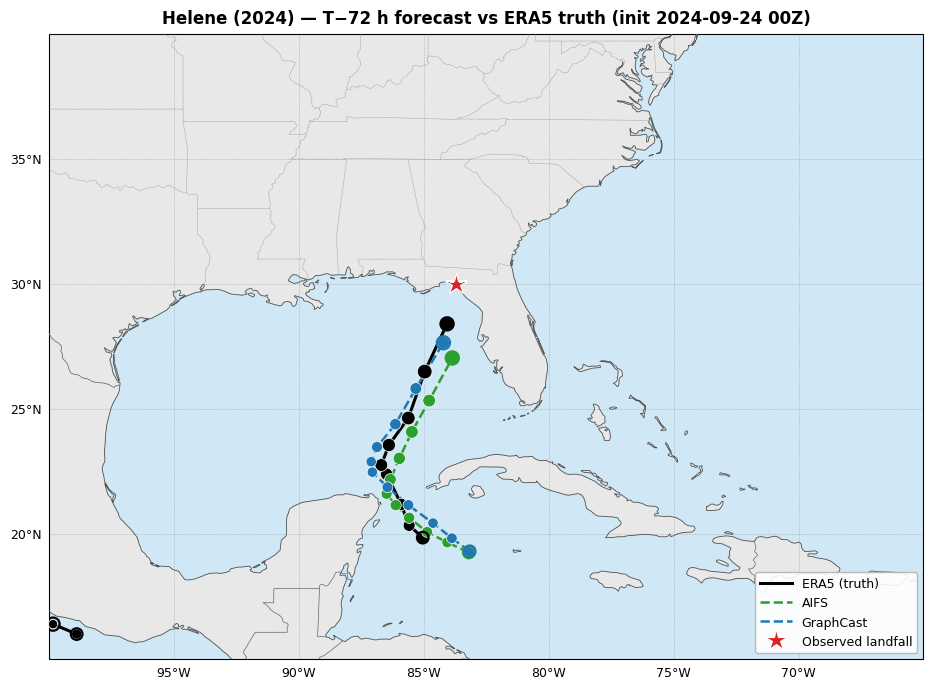

In [30]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_72, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_72, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_72,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−72 h forecast vs ERA5 truth (init {INIT_TIMES[72]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[72],
    nsteps=N_STEPS[72],
    save_path=OUT_DIR / "track_72h.png",
)

In [31]:
df_72 = make_error_table(72, {
    "ERA5 (truth)": era5_tracks_72,
    "AIFS":         aifs_tracks_72,
    "GraphCast":    gc_tracks_72,
})
print(f"\n=== T−72h position error (km) vs ERA5 truth ===\n")
print(df_72.to_string(index=False))


=== T−72h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  09-25 00Z            31                 77
  09-25 06Z            34                 91
  09-25 12Z            23                 95
  09-25 18Z            87                 59
  09-26 00Z            74                 44
  09-26 06Z            73                 49
  09-26 12Z            63                 59
  09-26 18Z           130                 83
  09-27 00Z           153                 85

saved → outputs/helene/track_168h.png

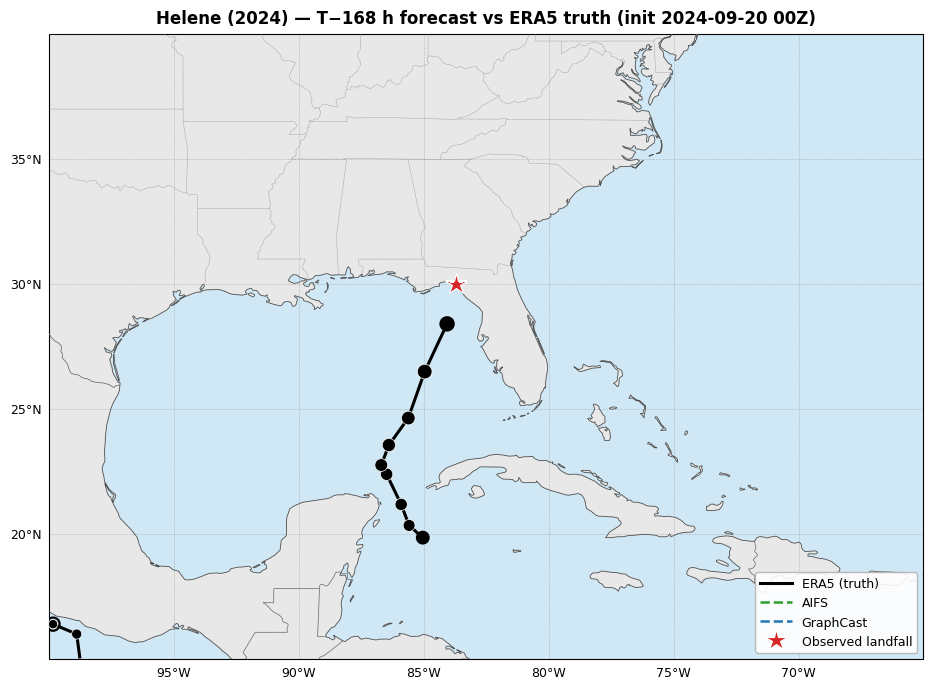

In [32]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_168, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_168, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_168,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−168 h forecast vs ERA5 truth (init {INIT_TIMES[168]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[168],
    nsteps=N_STEPS[168],
    save_path=OUT_DIR / "track_168h.png",
)

In [33]:
df_168 = make_error_table(168, {
    "ERA5 (truth)": era5_tracks_168,
    "AIFS":         aifs_tracks_168,
    "GraphCast":    gc_tracks_168,
})
print(f"\n=== T−168h position error (km) vs ERA5 truth ===\n")
print(df_168.to_string(index=False))


=== T−168h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  09-25 00Z            --                 --
  09-25 06Z            --                 --
  09-25 12Z            --                 --
  09-25 18Z            --                 --
  09-26 00Z            --                 --
  09-26 06Z            --                 --
  09-26 12Z            --                 --
  09-26 18Z            --                 --
  09-27 00Z          4439              12511

saved → outputs/helene/track_240h.png

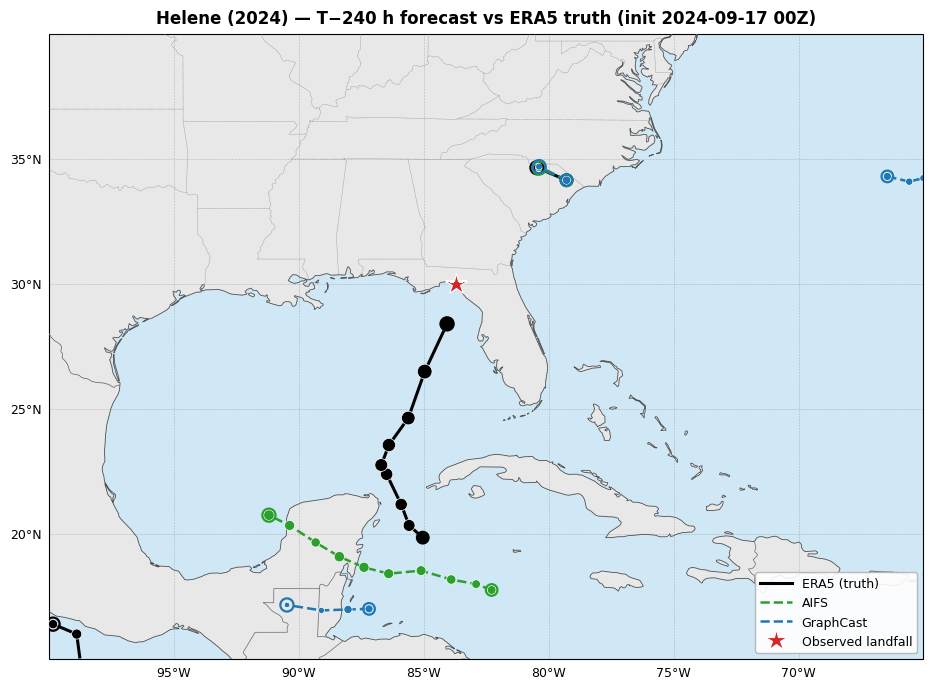

In [34]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_240, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_240, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_240,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−240 h forecast vs ERA5 truth (init {INIT_TIMES[240]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[240],
    nsteps=N_STEPS[240],
    save_path=OUT_DIR / "track_240h.png",
)

In [35]:
df_240 = make_error_table(240, {
    "ERA5 (truth)": era5_tracks_240,
    "AIFS":         aifs_tracks_240,
    "GraphCast":    gc_tracks_240,
})
print(f"\n=== T−240h position error (km) vs ERA5 trumaketh ===\n")
print(df_240.to_string(index=False))


=== T−240h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  09-25 00Z           305               2696
  09-25 06Z           298               2792
  09-25 12Z           306               2857
  09-25 18Z           442               2959
  09-26 00Z           461               3122
  09-26 06Z           537               3215
  09-26 12Z           672               3262
  09-26 18Z           879               3233
  09-27 00Z          1114               3179